# Visualization

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your results
df = pd.read_csv("../Results/RESULTS_SUMMARY.csv")

In [5]:
df

,config,C,gamma,percentile,patient,total_length_hours,TP,FP,FN,sensitivity,precision,f1,FP/day,FP/hour,latency_median,n_detected,mean_fold_roc_auc,mean_fold_ap
0,A,0.1,scale,5,chb01,35.552083,6,2,1,0.857143,0.750000,0.800000,1.350132,0.056255,29.00,6,0.957790,0.618479
1,A,0.1,scale,5,chb02,46.265972,1,51,2,0.333333,0.019231,0.036364,26.455729,1.102322,-29.00,1,0.648632,0.080014
2,A,0.1,scale,5,chb03,48.335417,3,5,4,0.428571,0.375000,0.400000,2.482652,0.103444,43.00,3,0.933222,0.243608
3,A,0.1,scale,5,chb04,204.526389,0,279,4,0.000000,0.000000,0.000000,32.739052,1.364127,NaN,0,0.835626,0.081890
4,A,0.1,scale,5,chb05,50.336806,4,14,1,0.800000,0.222222,0.347826,6.675036,0.278127,27.50,4,0.941490,0.548780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,E,0.1,0.01,10,chb01,35.552083,7,3,0,1.000000,0.700000,0.823529,2.025198,0.084383,30.50,7,0.940515,0.608954
93,E,0.1,0.01,10,chb02,46.265972,0,0,3,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0,0.721369,0.102851
94,E,0.1,0.01,10,chb03,48.335417,2,4,5,0.285714,0.333333,0.307692,1.986121,0.082755,66.75,2,0.929793,0.246890
95,E,0.1,0.01,10,chb04,204.526389,2,26,2,0.500000,0.071429,0.125000,3.050951,0.127123,27.00,2,0.858541,0.187734


# 1. Mean Performance per Configuration

In [10]:
summary = (
    df.groupby("config")
      .agg({
          "sensitivity":"mean",
          "precision":"mean",
          "f1":"mean",
          "FP/day":"mean",
          "mean_fold_ap":"mean",
          "mean_fold_roc_auc":"mean"
      })
)

print(summary.round(3))

        sensitivity  precision     f1  FP/day  mean_fold_ap  mean_fold_roc_auc
config                                                                        
A             0.471      0.273  0.289  17.184         0.340              0.873
B             0.510      0.294  0.333  13.712         0.372              0.883
C             0.528      0.324  0.353  16.961         0.381              0.882
D             0.484      0.270  0.301  16.362         0.351              0.876
E             0.477      0.231  0.270   6.752         0.334              0.878


# 2. Sensitivity per Configuration

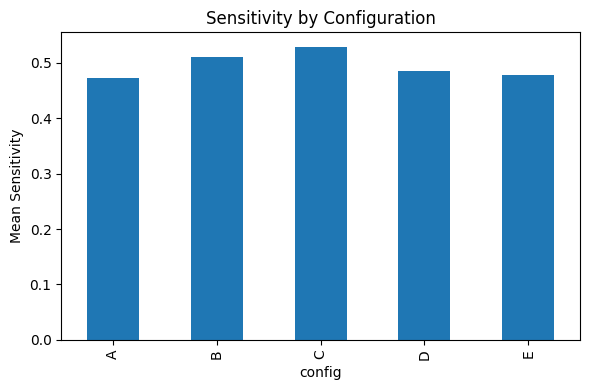

In [13]:
import matplotlib.pyplot as plt

config_summary = (
    df.groupby("config")["sensitivity"]
      .mean()
)

plt.figure(figsize=(6,4))
config_summary.plot(kind="bar")

plt.ylabel("Mean Sensitivity")
plt.title("Sensitivity by Configuration")

plt.tight_layout()
plt.show()

# 3. FP per Configuration

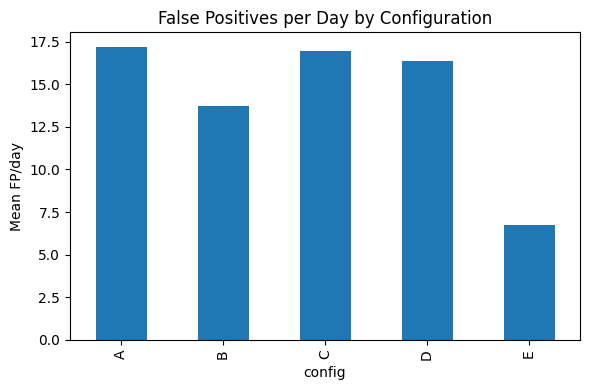

In [14]:
config_summary = (
    df.groupby("config")["FP/day"]
      .mean()
)

plt.figure(figsize=(6,4))
config_summary.plot(kind="bar")

plt.ylabel("Mean FP/day")
plt.title("False Positives per Day by Configuration")

plt.tight_layout()
plt.show()

# 4. Boxplot

<Figure size 800x500 with 0 Axes>

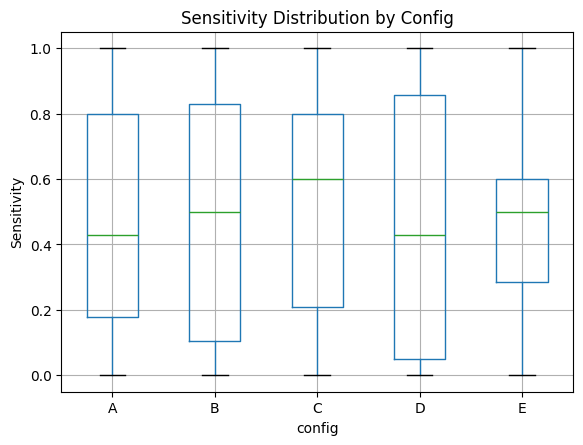

In [15]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="sensitivity",
    by="config"
)

plt.title("Sensitivity Distribution by Config")
plt.suptitle("")

plt.ylabel("Sensitivity")

plt.show()

# 5. Scatter plot

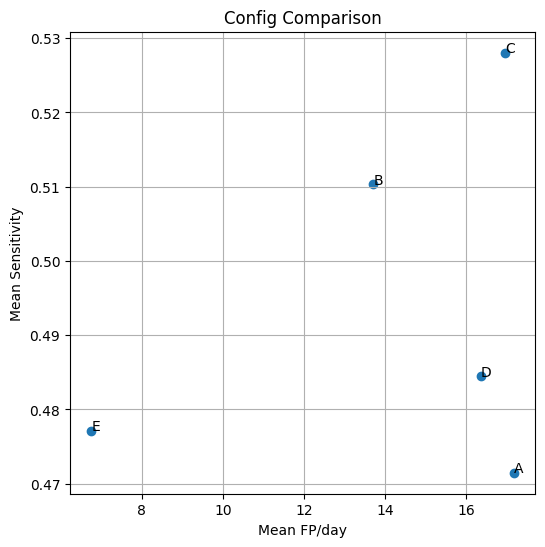

In [16]:
config_perf = (
    df.groupby("config")
      .agg({
          "sensitivity":"mean",
          "FP/day":"mean"
      })
      .reset_index()
)

plt.figure(figsize=(6,6))

plt.scatter(
    config_perf["FP/day"],
    config_perf["sensitivity"]
)

for _, row in config_perf.iterrows():
    plt.annotate(
        row["config"],
        (row["FP/day"], row["sensitivity"])
    )

plt.xlabel("Mean FP/day")
plt.ylabel("Mean Sensitivity")
plt.title("Config Comparison")

plt.grid(True)

plt.show()

# 6. Heatmap

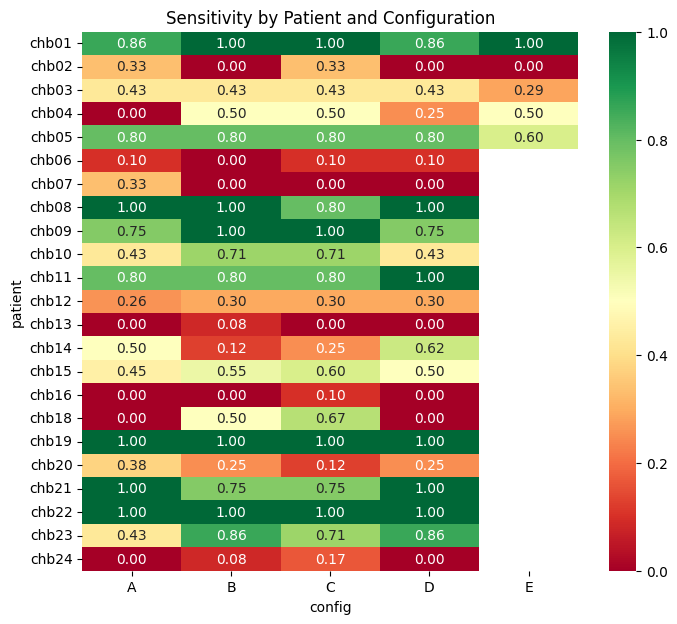

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df.pivot(
    index="patient",
    columns="config",
    values="sensitivity"
)

plt.figure(figsize=(8,7))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1
)

plt.title("Sensitivity by Patient and Configuration")
plt.show()